# 05 — Age-Adjusted Per-Channel Activation & Severity (GNG, HbO)

> **Re-analysis of §02 (group-level activation) and §04 (within-GAD severity)
> with age and sex as covariates** to address the 22-year HC–GAD age confound.
> Data source: `data/processed-new-mc/GNG/` (same as §01–§04). Ground-truth:
> `data/subjects_ground_truth.xlsx`.

## ⚠ IMPORTANT REMARK — Reduced sample size

This notebook **excludes the 11 GAD subjects flagged `demographics_missing=Y`**
because they lack age (and sex). Effective cohort:

- **HC** n = 33 (all retained)
- **GAD** n = 18  (38 % drop from §02/§04)
- Total = 51

> **Future-self note.** If/when the missing demographics for the 11 anxiety
> subjects (`AA089, AA090, AA092, AA093, AA094, AA097, AA098, AA099, LA091,
> LA095, LA096`) are recovered, **rerun this entire notebook** from the top.
> Specifically:
> 1. Update `data/subjects_ground_truth.xlsx` (or the equivalent merged source)
>    so those rows have valid `age`, `gender`, `education`, etc.
> 2. Re-execute `05_ancova_age_adjusted.ipynb` end-to-end.
> 3. The ANCOVA cohort will grow from 51 to 62, and the §04 partial-Spearman
>    correlations will use 29 GAD subjects instead of 18 — both of which will
>    materially change power and likely the significance map. Update
>    `REPORT.md`, the cross-references in §02 / §04 / `FUTURE_ANALYSES.md`,
>    and any paper text that cites n=51 / GAD=18.

## Methods overview

1. **Per-channel ANCOVA** — `HbO_STD ~ Group + Age + Sex` on the 51-subject
   cohort, per channel; report adjusted-Group beta, partial η², 95 % CI,
   raw + BH-FDR p. Compare significant-channel set against §02.
2. **Propensity-matched age-balanced subsample** — match HC/GAD on age via
   `psmpy` (logit propensity, caliper); rerun raw MWU on the matched subset;
   compare effect-size ranking with full-cohort §02.
3. **Within-GAD severity (partial Spearman)** — for the 18 GAD with age,
   compute partial-Spearman of HbO-STD vs (HAMA, STAI-T) controlling for age;
   compare with the §04 raw-Spearman ranking.

## Cohort caveats inherited from §01–§04

- `LA063` (GAD) HAMA = 0 (not administered) — excluded from HAMA correlations.
- `AH029` (HC) self-reported MDD; `AH024` (HC) ANS dysregulation — retained.


## 1. Imports & Configuration

In [1]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests
import pingouin as pg

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.labelsize': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'processed-new-mc')
TASK         = 'GNG'
GT_XLSX      = os.path.join(PROJECT_ROOT, 'data', 'subjects_ground_truth.xlsx')
OUT_DIR      = os.path.join(PROJECT_ROOT, 'src', 'notebook', 'statistical-analysis', '05_age_adjusted')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

CHANNEL_NAMES = [
    'S1_D1','S1_D3','S2_D2','S2_D1','S2_D5','S3_D1','S3_D3','S3_D4','S3_D6',
    'S4_D4','S4_D5','S4_D7','S5_D2','S5_D5','S5_D8','S6_D3','S6_D6',
    'S7_D4','S7_D6','S7_D7','S8_D5','S8_D7','S8_D8',
]
GRID_POS = [(0,2),(1,1),(0,4),(0,3),(1,4),(1,2),(2,1),(2,2),(3,1),
            (2,3),(2,4),(3,4),(1,5),(2,5),(3,6),(3,0),(4,1),
            (3,2),(4,2),(4,3),(3,5),(4,4),(4,5)]
GRID_SHAPE = (5, 7); N_CH = len(CHANNEL_NAMES)
CH_TO_IDX = {ch: i for i, ch in enumerate(CHANNEL_NAMES)}
def values_to_grid(v, fill=np.nan):
    g = np.full(GRID_SHAPE, fill, dtype=float)
    for i, (r, c) in enumerate(GRID_POS): g[r, c] = v[i]
    return g


PROJECT_ROOT = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method


## 2. Build Cohort DataFrame (HbO STD per channel + demographics)

In [2]:
def load_activation(subject_id, group, hb='hbo'):
    path  = os.path.join(DATA_DIR, TASK, group, subject_id, hb)
    files = sorted(os.listdir(path))
    concat = np.concatenate([np.load(os.path.join(path, f)) for f in files], axis=1)
    return concat.std(axis=1)  # (23,)

HC_IDS  = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'healthy')))
GAD_IDS = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'anxiety')))
gt = pd.read_excel(GT_XLSX).set_index('subject_id')

rows = []
for s in HC_IDS:
    a = load_activation(s, 'healthy')
    rows.append({'subject_id': s, 'group': 'HC',
                 'age': gt.loc[s, 'age'], 'gender': gt.loc[s, 'gender'],
                 'demographics_missing': gt.loc[s, 'demographics_missing'],
                 'HAMA_sum': gt.loc[s, 'HAMA_sum'], 'STAIT_sum': gt.loc[s, 'STAIT_sum'],
                 **{ch: a[i] for i, ch in enumerate(CHANNEL_NAMES)}})
for s in GAD_IDS:
    a = load_activation(s, 'anxiety')
    rows.append({'subject_id': s, 'group': 'GAD',
                 'age': gt.loc[s, 'age'], 'gender': gt.loc[s, 'gender'],
                 'demographics_missing': gt.loc[s, 'demographics_missing'],
                 'HAMA_sum': gt.loc[s, 'HAMA_sum'], 'STAIT_sum': gt.loc[s, 'STAIT_sum'],
                 **{ch: a[i] for i, ch in enumerate(CHANNEL_NAMES)}})

df_full = pd.DataFrame(rows)
print(f'Full cohort (62 subjects): {df_full.shape}')

# Demographics-eligible
df = df_full[df_full['demographics_missing'] != 'Y'].copy()
df['Sex'] = df['gender'].map({'女': 'F', '男': 'M'})
df['Group'] = pd.Categorical(df['group'], categories=['HC', 'GAD'])  # HC = reference
df = df.dropna(subset=['age','Sex']).reset_index(drop=True)

print(f'Demographics-eligible cohort (n={len(df)}): HC={(df["group"]=="HC").sum()}, GAD={(df["group"]=="GAD").sum()}')
print(f'  Excluded: {sorted(df_full[df_full["demographics_missing"]=="Y"]["subject_id"].tolist())}')
print()
print(df[['group','age']].groupby('group').agg(['count','mean','std','min','max']))


Full cohort (62 subjects): (62, 30)
Demographics-eligible cohort (n=51): HC=33, GAD=18
  Excluded: ['AA089', 'AA090', 'AA092', 'AA093', 'AA094', 'AA097', 'AA098', 'AA099', 'LA091', 'LA095', 'LA096']

        age                                  
      count       mean        std   min   max
group                                        
GAD      18  51.111111  14.724485  29.0  75.0
HC       33  73.030303   5.564872  65.0  85.0


## 3. Per-Channel ANCOVA — `HbO_STD ~ Group + Age + Sex`

In [3]:
ancova_rows = []
for ch in CHANNEL_NAMES:
    formula = f'Q("{ch}") ~ C(Group, Treatment(reference="HC")) + age + C(Sex)'
    model = smf.ols(formula, data=df).fit()
    # Group effect: coefficient on the GAD dummy
    coef_name = [n for n in model.params.index if 'GAD' in n][0]
    beta  = model.params[coef_name]
    se    = model.bse[coef_name]
    p     = model.pvalues[coef_name]
    ci_lo, ci_hi = model.conf_int().loc[coef_name].tolist()
    # Partial eta² for Group via type-II ANOVA
    aov = sm.stats.anova_lm(model, typ=2)
    grp_row = aov.loc[[i for i in aov.index if 'Group' in i][0]]
    ss_grp  = grp_row['sum_sq']
    ss_res  = aov.loc['Residual', 'sum_sq']
    eta_p   = ss_grp / (ss_grp + ss_res)
    age_p   = aov.loc['age', 'PR(>F)']
    ancova_rows.append({
        'channel': ch, 'beta_group': beta, 'se': se, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'p_group_adj': p, 'partial_eta2_group': eta_p, 'p_age': age_p,
        'r2_full': model.rsquared,
    })
ancova_df = pd.DataFrame(ancova_rows)
ancova_df['p_fdr_adj'] = multipletests(ancova_df['p_group_adj'].values, method='fdr_bh')[1]
ancova_df['sig_raw_adj'] = ancova_df['p_group_adj'] < 0.05
ancova_df['sig_fdr_adj'] = ancova_df['p_fdr_adj']   < 0.05

print(f'ANCOVA (Group+Age+Sex), n={len(df)}')
print(f'  Channels p<.05 (adjusted, raw)  : {ancova_df["sig_raw_adj"].sum()}/23')
print(f'  Channels q<.05 (adjusted, FDR)  : {ancova_df["sig_fdr_adj"].sum()}/23')
print(f'  Channels with p_age<.05         : {(ancova_df["p_age"]<0.05).sum()}/23  (age explains variance there)')
print()
print('Top-5 channels by adjusted-Group p:')
print(ancova_df.sort_values('p_group_adj').head(5)[
    ['channel','beta_group','ci_lo','ci_hi','partial_eta2_group','p_group_adj','p_fdr_adj','p_age']
].to_string(index=False, float_format=lambda x: f'{x:.4g}'))


ANCOVA (Group+Age+Sex), n=51
  Channels p<.05 (adjusted, raw)  : 7/23
  Channels q<.05 (adjusted, FDR)  : 0/23
  Channels with p_age<.05         : 3/23  (age explains variance there)

Top-5 channels by adjusted-Group p:
channel  beta_group    ci_lo     ci_hi  partial_eta2_group  p_group_adj  p_fdr_adj   p_age
  S5_D5    -0.04821 -0.07826  -0.01816              0.1815     0.002275    0.05234  0.1588
  S8_D5    -0.04391 -0.07635  -0.01147              0.1362     0.009057     0.1042 0.02703
  S4_D7    -0.04116 -0.07451 -0.007812               0.116      0.01666     0.1136 0.04538
  S3_D1    -0.03838 -0.07036 -0.006389              0.1103      0.01975     0.1136  0.3203
  S2_D1    -0.03252 -0.06271 -0.002329             0.09083      0.03534     0.1454  0.4904


## 4. Compare With §02 (Unadjusted MWU) — Same Cohort vs Full Cohort

In [4]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (b.mean() - a.mean()) / s if s > 0 else 0.0

# (a) §02 — full cohort raw MWU
mwu_full_rows = []
for ch in CHANNEL_NAMES:
    a = df_full[df_full['group']=='HC'][ch].values
    b = df_full[df_full['group']=='GAD'][ch].values
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    mwu_full_rows.append({'channel': ch, 'U': U, 'p_raw_full': p, 'd_full': cohens_d(a, b)})
mwu_full = pd.DataFrame(mwu_full_rows)
mwu_full['p_fdr_full'] = multipletests(mwu_full['p_raw_full'], method='fdr_bh')[1]

# (b) Same MWU restricted to demographics-eligible subset (no covariates) — fair compare to ANCOVA
mwu_elig_rows = []
for ch in CHANNEL_NAMES:
    a = df[df['group']=='HC'][ch].values
    b = df[df['group']=='GAD'][ch].values
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    mwu_elig_rows.append({'channel': ch, 'U': U, 'p_raw_elig': p, 'd_elig': cohens_d(a, b)})
mwu_elig = pd.DataFrame(mwu_elig_rows)
mwu_elig['p_fdr_elig'] = multipletests(mwu_elig['p_raw_elig'], method='fdr_bh')[1]

# Merge
cmp = (ancova_df
       .merge(mwu_full[['channel','d_full','p_raw_full','p_fdr_full']], on='channel')
       .merge(mwu_elig[['channel','d_elig','p_raw_elig','p_fdr_elig']], on='channel'))

print('Sig-channel summary across the three analyses:')
print(f'  §02   full N=62  unadjusted MWU : {(cmp["p_raw_full"]<0.05).sum()}/23 raw, {(cmp["p_fdr_full"]<0.05).sum()}/23 FDR')
print(f'  §05a  N=51       unadjusted MWU : {(cmp["p_raw_elig"]<0.05).sum()}/23 raw, {(cmp["p_fdr_elig"]<0.05).sum()}/23 FDR')
print(f'  §05b  N=51       ANCOVA Group+Age+Sex : {(cmp["sig_raw_adj"]).sum()}/23 raw, {(cmp["sig_fdr_adj"]).sum()}/23 FDR')

print()
print('Channel-by-channel comparison (top by §05 p_group_adj):')
view = cmp.sort_values('p_group_adj').head(8)[
    ['channel','d_full','p_raw_full','d_elig','p_raw_elig','beta_group','p_group_adj','partial_eta2_group','p_fdr_adj']
].rename(columns={'beta_group':'beta_adj','p_group_adj':'p_adj','partial_eta2_group':'eta2','p_fdr_adj':'p_fdr_adj'})
print(view.to_string(index=False, float_format=lambda x: f'{x:.3g}'))


Sig-channel summary across the three analyses:
  §02   full N=62  unadjusted MWU : 10/23 raw, 4/23 FDR
  §05a  N=51       unadjusted MWU : 8/23 raw, 0/23 FDR
  §05b  N=51       ANCOVA Group+Age+Sex : 7/23 raw, 0/23 FDR

Channel-by-channel comparison (top by §05 p_group_adj):
channel  d_full  p_raw_full  d_elig  p_raw_elig  beta_adj   p_adj   eta2  p_fdr_adj
  S5_D5  -0.919     0.00087  -0.956     0.00283   -0.0482 0.00228  0.181     0.0523
  S8_D5  -0.331       0.259  -0.471       0.218   -0.0439 0.00906  0.136      0.104
  S4_D7  -0.389       0.135  -0.445       0.142   -0.0412  0.0167  0.116      0.114
  S3_D1  -0.558      0.0298  -0.743      0.0166   -0.0384  0.0197   0.11      0.114
  S2_D1  -0.925      0.0013  -0.745      0.0206   -0.0325  0.0353 0.0908      0.145
  S5_D8  -0.519      0.0533   -0.57      0.0777   -0.0385  0.0379 0.0885      0.145
  S7_D4  0.0331       0.877  -0.151       0.588   -0.0425  0.0451 0.0827      0.148
  S8_D7  -0.267       0.463  -0.283       0.574   -0

## 5. Topographic Comparison — §02 d vs §05 ANCOVA β

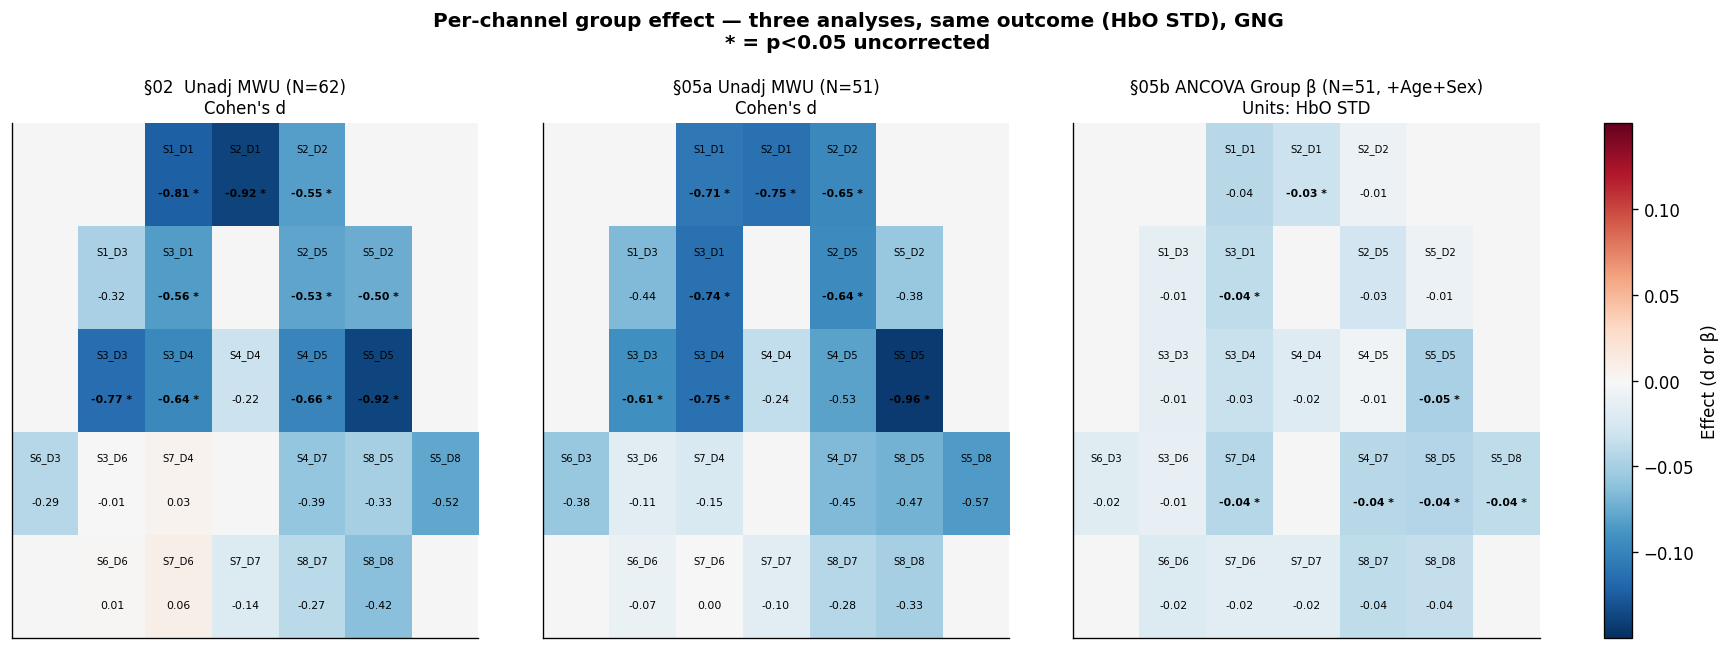

Saved: fig_ancova_vs_unadj_topo.png


In [5]:
def plot_topo(ax, vals, sig_mask, title, vmax, units=''):
    grid = values_to_grid(vals)
    ax.set_facecolor('#f5f5f5')
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(grid, cmap='RdBu_r', norm=norm, aspect='auto')
    for i, (r, c) in enumerate(GRID_POS):
        marker = ' *' if sig_mask[i] else ''
        ax.text(c, r-0.25, CHANNEL_NAMES[i], ha='center', va='center', fontsize=6)
        ax.text(c, r+0.18, f'{vals[i]:.2f}{marker}', ha='center', va='center',
                fontsize=6.5, fontweight='bold' if sig_mask[i] else 'normal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10, pad=6)
    return im

fig = plt.figure(figsize=(15, 5.5))
gs  = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.06], wspace=0.18)
ax_a, ax_b, ax_c = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax = fig.add_subplot(gs[0, 3])
fig.suptitle('Per-channel group effect — three analyses, same outcome (HbO STD), GNG\n* = p<0.05 uncorrected',
             fontsize=12, fontweight='bold', y=0.99)

# (a) §02 full N=62, Cohen's d
plot_topo(ax_a, cmp['d_full'].values, (cmp['p_raw_full']<0.05).values,
          f'§02  Unadj MWU (N=62)\nCohen\'s d', vmax=1.0)
# (b) §05a same cohort, Cohen's d
plot_topo(ax_b, cmp['d_elig'].values, (cmp['p_raw_elig']<0.05).values,
          f'§05a Unadj MWU (N=51)\nCohen\'s d', vmax=1.0)
# (c) §05b ANCOVA β (group coefficient, units of HbO STD)
beta_max = max(np.abs(cmp['beta_group']).max(), 0.15)
im = plot_topo(ax_c, cmp['beta_group'].values, cmp['sig_raw_adj'].values,
               f'§05b ANCOVA Group β (N=51, +Age+Sex)\nUnits: HbO STD', vmax=beta_max)

cb = fig.colorbar(im, cax=cax); cb.set_label('Effect (d or β)')
fig.subplots_adjust(top=0.82, bottom=0.04, left=0.03, right=0.93)
fig.savefig(os.path.join(OUT_DIR, 'fig_ancova_vs_unadj_topo.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_ancova_vs_unadj_topo.png')


## 6. Age-Matched Subsample (Propensity Matching)

Match HC and GAD on `age` via logistic-propensity matching with a caliper, to
produce a smaller but age-balanced subset, then rerun raw MWU.

In [6]:
# Simpler, transparent 1:1 nearest-neighbour age-matching (no caliper needed
# since the GAD pool is what we want to keep). For each GAD, find the HC with
# closest age that hasn't been used yet.

from scipy.spatial import cKDTree

hc  = df[df['group']=='HC' ].reset_index(drop=True).copy()
gad = df[df['group']=='GAD'].reset_index(drop=True).copy()
hc_ages  = hc['age'].values.reshape(-1, 1)
gad_ages = gad['age'].values

used = np.zeros(len(hc), dtype=bool)
matched_pairs = []
for i, ga in enumerate(gad_ages):
    candidates = np.where(~used)[0]
    if len(candidates) == 0: break
    nn = candidates[np.argmin(np.abs(hc_ages[candidates, 0] - ga))]
    used[nn] = True
    matched_pairs.append((gad.loc[i, 'subject_id'], hc.loc[nn, 'subject_id'],
                          ga, hc.loc[nn, 'age']))

matched_pairs_df = pd.DataFrame(matched_pairs, columns=['gad_id','hc_id','gad_age','hc_age'])
matched_pairs_df['delta_age'] = matched_pairs_df['hc_age'] - matched_pairs_df['gad_age']
print('Age-matched pairs:')
print(matched_pairs_df.to_string(index=False))
print(f'\nMean |Δage| = {matched_pairs_df["delta_age"].abs().mean():.1f} yr')

matched_ids = matched_pairs_df['gad_id'].tolist() + matched_pairs_df['hc_id'].tolist()
df_match = df[df['subject_id'].isin(matched_ids)].copy().reset_index(drop=True)

print(f'\nMatched cohort: HC={(df_match["group"]=="HC").sum()}, '
      f'GAD={(df_match["group"]=="GAD").sum()} (total {len(df_match)})')
print()
print(df_match[['group','age']].groupby('group').agg(['count','mean','std','min','max']))

# Welch t on matched ages — should be non-significant if matching worked
t_age, p_age = stats.ttest_ind(
    df_match[df_match['group']=='HC']['age'],
    df_match[df_match['group']=='GAD']['age'], equal_var=False)
print(f'\nMatched-age Welch t: t={t_age:.2f}, p={p_age:.3g}  (target: ns)')

# Per-channel MWU on matched subset
match_rows = []
for ch in CHANNEL_NAMES:
    a = df_match[df_match['group']=='HC'][ch].values
    b = df_match[df_match['group']=='GAD'][ch].values
    if len(a) < 4 or len(b) < 4:
        match_rows.append({'channel': ch, 'd_match': np.nan, 'p_raw_match': np.nan})
        continue
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    match_rows.append({'channel': ch, 'd_match': cohens_d(a, b), 'p_raw_match': p})
match_df = pd.DataFrame(match_rows)
match_df['p_fdr_match'] = multipletests(match_df['p_raw_match'].fillna(1), method='fdr_bh')[1]
match_df['sig_raw_match'] = match_df['p_raw_match'] < 0.05

print(f'\nMatched-cohort MWU: {(match_df["p_raw_match"]<0.05).sum()}/23 raw, '
      f'{(match_df["p_fdr_match"]<0.05).sum()}/23 FDR')
print('\nTop-5 channels (matched cohort):')
print(match_df.sort_values('p_raw_match').head(5).to_string(index=False, float_format=lambda x: f'{x:.4g}'))


Age-matched pairs:
gad_id hc_id  gad_age  hc_age  delta_age
 AA011 AH015     75.0    75.0        0.0
 AA013 AH027     64.0    65.0        1.0
 AA041 AH023     70.0    70.0        0.0
 AA056 AH049     62.0    65.0        3.0
 AA064 AH039     67.0    67.0        0.0
 EA055 AH026     34.0    66.0       32.0
 EA060 AH044     29.0    66.0       37.0
 EA061 AH046     51.0    67.0       16.0
 EA062 AH018     46.0    68.0       22.0
 LA042 AH014     49.0    69.0       20.0
 LA051 AH033     29.0    69.0       40.0
 LA052 AH036     56.0    69.0       13.0
 LA053 AH045     53.0    69.0       16.0
 LA054 AH037     35.0    70.0       35.0
 LA057 AH022     33.0    71.0       38.0
 LA058 AH028     61.0    72.0       11.0
 LA059 AH050     63.0    72.0        9.0
 LA063 AH038     43.0    73.0       30.0

Mean |Δage| = 17.9 yr

Matched cohort: HC=18, GAD=18 (total 36)

        age                                  
      count       mean        std   min   max
group                                       

## 6.b Sensitivity: Age-Overlap Subsample (HC ≥ 65 ∩ GAD ≥ 60)

The propensity-matched cohort above does **not** achieve age balance: the HC
ages (65–85) and the GAD ages (29–75) overlap only weakly. To check that the
group effects in §02 are not entirely an aging artefact, we restrict to the
**age-overlap range** (HC ≥ 65 by definition, GAD ≥ 60) and rerun MWU.

In [7]:
df_overlap = df[(df['age'] >= 60)].copy().reset_index(drop=True)
n_hc = (df_overlap['group']=='HC').sum()
n_gad = (df_overlap['group']=='GAD').sum()
print(f'Age-overlap subsample (age ≥ 60): HC={n_hc}, GAD={n_gad}')

t_age2, p_age2 = stats.ttest_ind(
    df_overlap[df_overlap['group']=='HC']['age'],
    df_overlap[df_overlap['group']=='GAD']['age'], equal_var=False)
print(f'Welch t (overlap subsample): t={t_age2:.2f}, p={p_age2:.3g}')

ovl_rows = []
for ch in CHANNEL_NAMES:
    a = df_overlap[df_overlap['group']=='HC'][ch].values
    b = df_overlap[df_overlap['group']=='GAD'][ch].values
    if len(a) < 4 or len(b) < 4:
        ovl_rows.append({'channel': ch, 'd_overlap': np.nan, 'p_raw_overlap': np.nan})
        continue
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    ovl_rows.append({'channel': ch, 'd_overlap': cohens_d(a, b), 'p_raw_overlap': p})
overlap_df = pd.DataFrame(ovl_rows)
overlap_df['p_fdr_overlap'] = multipletests(overlap_df['p_raw_overlap'].fillna(1), method='fdr_bh')[1]

print(f'\nOverlap-subsample MWU: {(overlap_df["p_raw_overlap"]<0.05).sum()}/23 raw, '
      f'{(overlap_df["p_fdr_overlap"]<0.05).sum()}/23 FDR')
print('\nTop-5 channels (overlap subsample):')
print(overlap_df.sort_values('p_raw_overlap').head(5).to_string(index=False, float_format=lambda x: f'{x:.4g}'))


Age-overlap subsample (age ≥ 60): HC=33, GAD=7
Welch t (overlap subsample): t=3.29, p=0.0088

Overlap-subsample MWU: 4/23 raw, 0/23 FDR

Top-5 channels (overlap subsample):
channel  d_overlap  p_raw_overlap  p_fdr_overlap
  S1_D1     -1.169       0.007155        0.08228
  S5_D5      -1.26       0.007155        0.08228
  S8_D7     -1.187        0.03356         0.2332
  S5_D8     -0.986        0.04056         0.2332
  S4_D7    -0.8645        0.06326         0.2587


## 7. Within-GAD Severity — Partial Spearman Controlling for Age

Re-runs §04 with age regressed out. Only the 18 GAD with valid age can be
used (down from 29).

In [8]:
gad_demo = df[df['group']=='GAD'].copy().reset_index(drop=True)
print(f'GAD with age available: n={len(gad_demo)} (vs 29 in §04)')
print(f'  ages: {gad_demo["age"].describe().round(1).to_dict()}')

# Build the per-channel HbO activation matrix for these GAD subjects
act_gad = gad_demo[CHANNEL_NAMES].values  # (18, 23)
stait   = gad_demo['STAIT_sum'].values.astype(float)
hama_full = gad_demo['HAMA_sum'].values.astype(float)
hama_mask = hama_full > 0
hama_vals = hama_full[hama_mask]

print(f'  STAI-T n={len(stait)}, mean={stait.mean():.1f}±{stait.std(ddof=1):.1f}')
print(f'  HAMA   n={hama_mask.sum()} (LA063 excluded if present), '
      f'mean={hama_vals.mean():.1f}±{hama_vals.std(ddof=1):.1f}')

def partial_spearman(x, y, z):
    """Spearman partial correlation of x,y given z (regress z out then Spearman residuals)."""
    rx = stats.linregress(z, x).intercept + stats.linregress(z, x).slope * z
    ry = stats.linregress(z, y).intercept + stats.linregress(z, y).slope * z
    res_x = x - rx; res_y = y - ry
    return stats.spearmanr(res_x, res_y)

partial_rows = []
ages_gad = gad_demo['age'].values.astype(float)
for ch_i, ch in enumerate(CHANNEL_NAMES):
    # raw vs partial — STAIT
    r_raw, p_raw = stats.spearmanr(act_gad[:, ch_i], stait)
    r_par, p_par = partial_spearman(act_gad[:, ch_i], stait, ages_gad)
    partial_rows.append({'measure': 'STAIT', 'channel': ch, 'n': len(stait),
                         'r_raw_n18': r_raw, 'p_raw_n18': p_raw,
                         'r_partial_age': r_par, 'p_partial_age': p_par})
    # HAMA — restrict to subjects with HAMA > 0
    a = act_gad[hama_mask, ch_i]
    h = hama_vals
    z_sub = ages_gad[hama_mask]
    r_raw_h, p_raw_h = stats.spearmanr(a, h)
    r_par_h, p_par_h = partial_spearman(a, h, z_sub)
    partial_rows.append({'measure': 'HAMA', 'channel': ch, 'n': hama_mask.sum(),
                         'r_raw_n18': r_raw_h, 'p_raw_n18': p_raw_h,
                         'r_partial_age': r_par_h, 'p_partial_age': p_par_h})
partial_df = pd.DataFrame(partial_rows)
# FDR per measure
for m in ['STAIT','HAMA']:
    sub = partial_df[partial_df['measure']==m]
    partial_df.loc[sub.index, 'p_fdr_raw_n18']     = multipletests(sub['p_raw_n18'].values, method='fdr_bh')[1]
    partial_df.loc[sub.index, 'p_fdr_partial_age'] = multipletests(sub['p_partial_age'].values, method='fdr_bh')[1]

print('\nSig-channel comparison (raw Spearman on n=18 vs partial-Spearman | age):')
for m in ['STAIT','HAMA']:
    sub = partial_df[partial_df['measure']==m]
    print(f'  {m}: raw     {(sub["p_raw_n18"]<0.05).sum()}/23 (FDR {(sub["p_fdr_raw_n18"]<0.05).sum()}/23)')
    print(f'  {m}: partial {(sub["p_partial_age"]<0.05).sum()}/23 (FDR {(sub["p_fdr_partial_age"]<0.05).sum()}/23)')

print('\nTop-5 partial correlations per measure:')
for m in ['STAIT','HAMA']:
    print(f'\n--- {m} ---')
    print(partial_df[partial_df['measure']==m].sort_values('p_partial_age').head(5)[
        ['channel','r_raw_n18','p_raw_n18','r_partial_age','p_partial_age']
    ].to_string(index=False, float_format=lambda x: f'{x:.4g}'))


GAD with age available: n=18 (vs 29 in §04)
  ages: {'count': 18.0, 'mean': 51.1, 'std': 14.7, 'min': 29.0, '25%': 37.0, '50%': 52.0, '75%': 62.8, 'max': 75.0}
  STAI-T n=18, mean=57.8±7.8
  HAMA   n=17 (LA063 excluded if present), mean=23.8±8.6

Sig-channel comparison (raw Spearman on n=18 vs partial-Spearman | age):
  STAIT: raw     0/23 (FDR 0/23)
  STAIT: partial 0/23 (FDR 0/23)
  HAMA: raw     0/23 (FDR 0/23)
  HAMA: partial 0/23 (FDR 0/23)

Top-5 partial correlations per measure:

--- STAIT ---
channel  r_raw_n18  p_raw_n18  r_partial_age  p_partial_age
  S8_D5     -0.381     0.1188        -0.4159        0.08606
  S3_D4    -0.3333     0.1765        -0.3684         0.1325
  S7_D4    -0.1491      0.555        -0.3664         0.1348
  S8_D8    -0.3219     0.1926        -0.3148         0.2033
  S5_D2    -0.2464     0.3244        -0.2879         0.2466

--- HAMA ---
channel  r_raw_n18  p_raw_n18  r_partial_age  p_partial_age
  S7_D4    -0.2908     0.2575        -0.4387        0.07812


## 8. Visualizations — ANCOVA β Topomap and Severity Comparison

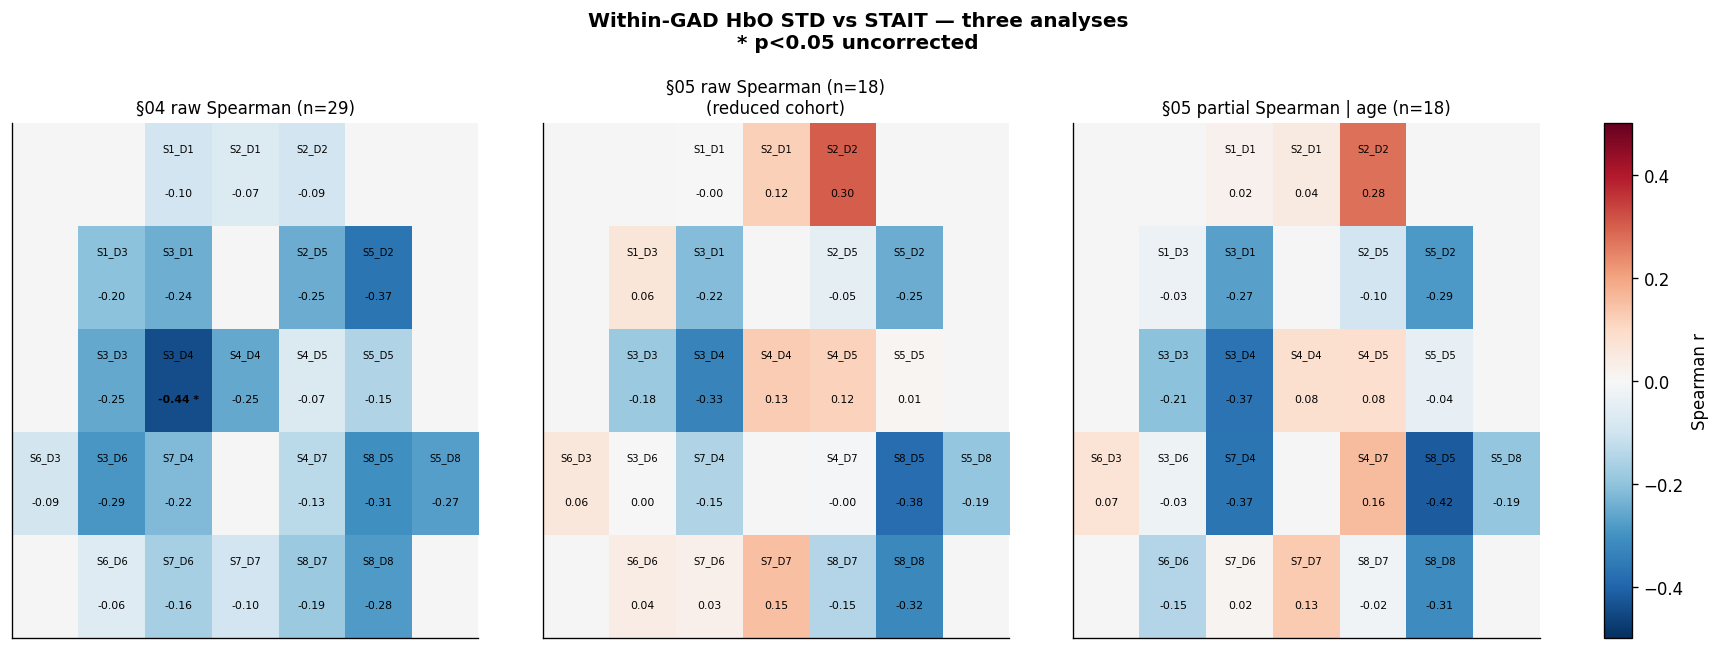

Saved: fig_partial_spearman_stait.png


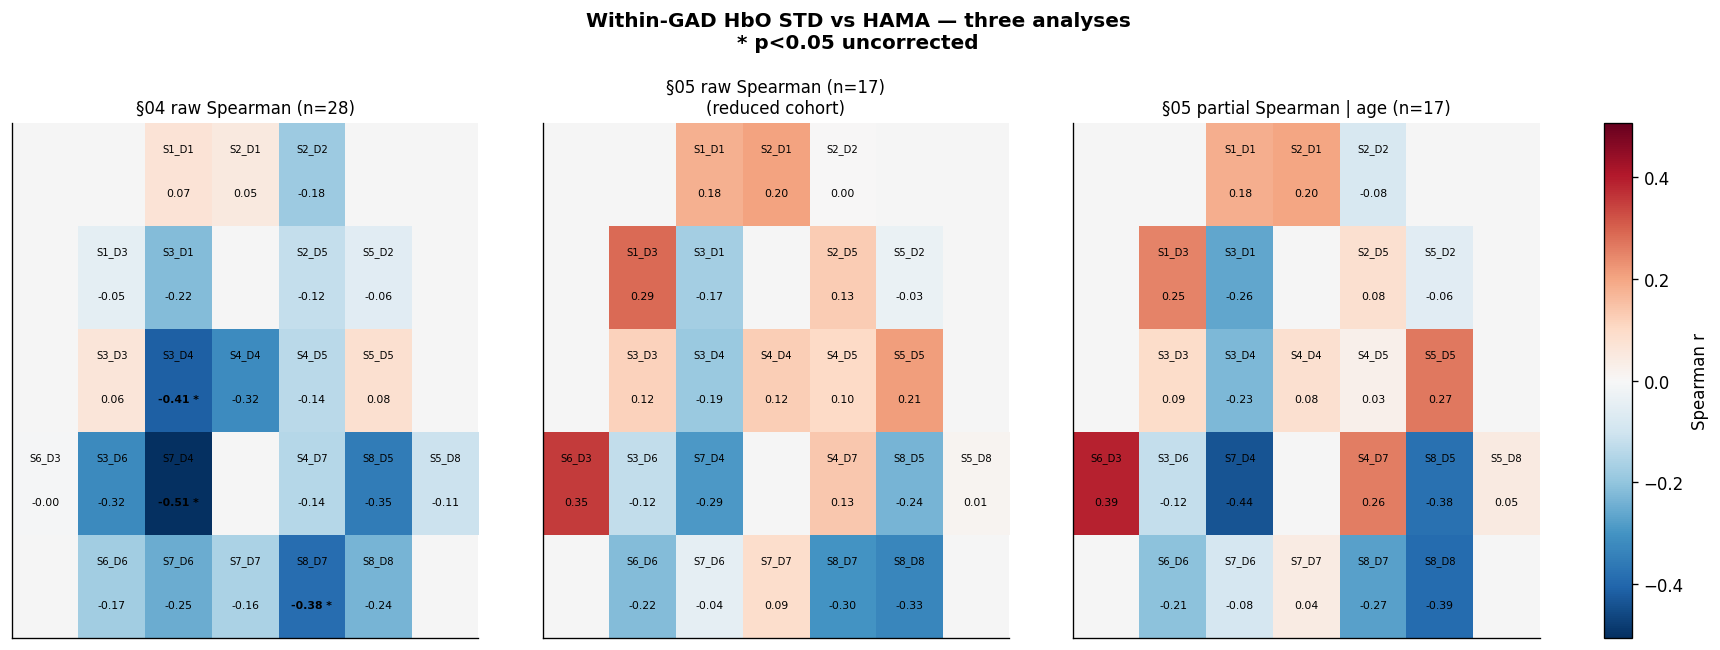

Saved: fig_partial_spearman_hama.png


In [9]:
# Comparison topomap: §04 raw r (n=29) vs §05 raw r (n=18) vs partial r (n=18) — STAIT
def make_partial_view(measure):
    sub = partial_df[partial_df['measure']==measure].set_index('channel')
    return (sub.loc[CHANNEL_NAMES, 'r_raw_n18'].values,
            sub.loc[CHANNEL_NAMES, 'p_raw_n18'].values,
            sub.loc[CHANNEL_NAMES, 'r_partial_age'].values,
            sub.loc[CHANNEL_NAMES, 'p_partial_age'].values)

# Load §04 results for comparison
sev04 = pd.read_csv(os.path.join(PROJECT_ROOT, 'src','notebook','statistical-analysis',
                                 '04_severity_correlation', 'results_severity_correlation.csv'))

def get04(measure):
    sub = sev04[sev04['measure']==measure].set_index('channel')
    return sub.loc[CHANNEL_NAMES, 'r'].values, sub.loc[CHANNEL_NAMES, 'p_raw'].values

for measure in ['STAIT','HAMA']:
    r04, p04 = get04(measure)
    r_raw18, p_raw18, r_par, p_par = make_partial_view(measure)
    vmax = max(np.abs(np.concatenate([r04, r_raw18, r_par])).max(), 0.5)
    fig = plt.figure(figsize=(15, 5.5))
    gs  = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.06], wspace=0.18)
    axs = [fig.add_subplot(gs[0, i]) for i in range(3)]
    cax = fig.add_subplot(gs[0, 3])
    fig.suptitle(f'Within-GAD HbO STD vs {measure} — three analyses\n* p<0.05 uncorrected',
                 fontsize=12, fontweight='bold', y=0.99)
    plot_topo(axs[0], r04,    p04   <0.05, f'§04 raw Spearman (n={29 if measure=="STAIT" else 28})', vmax)
    plot_topo(axs[1], r_raw18,p_raw18<0.05, f'§05 raw Spearman (n={18 if measure=="STAIT" else 17})\n(reduced cohort)', vmax)
    im = plot_topo(axs[2], r_par,  p_par <0.05, f'§05 partial Spearman | age (n={18 if measure=="STAIT" else 17})', vmax)
    cb = fig.colorbar(im, cax=cax); cb.set_label('Spearman r')
    fig.subplots_adjust(top=0.82, bottom=0.04, left=0.03, right=0.93)
    fig.savefig(os.path.join(OUT_DIR, f'fig_partial_spearman_{measure.lower()}.png'),
                bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: fig_partial_spearman_{measure.lower()}.png')


## 9. Summary & CSV Export

In [11]:
# Save all the analysis tables
ancova_out = ancova_df.copy()
ancova_out['task'] = TASK
ancova_out.to_csv(os.path.join(OUT_DIR, 'results_ancova_age_sex.csv'), index=False, float_format='%.6f')

cmp_out = cmp.copy()
cmp_out.to_csv(os.path.join(OUT_DIR, 'results_unadj_vs_ancova_compare.csv'), index=False, float_format='%.6f')

match_out = match_df.copy()
match_out.to_csv(os.path.join(OUT_DIR, 'results_age_matched_mwu.csv'), index=False, float_format='%.6f')

overlap_out = overlap_df.copy()
overlap_out.to_csv(os.path.join(OUT_DIR, 'results_age_overlap_mwu.csv'), index=False, float_format='%.6f')

partial_out = partial_df.copy()
partial_out.to_csv(os.path.join(OUT_DIR, 'results_partial_spearman_severity.csv'), index=False, float_format='%.6f')

print('Files saved:')
for f in ['results_ancova_age_sex.csv','results_unadj_vs_ancova_compare.csv',
          'results_age_matched_mwu.csv','results_age_overlap_mwu.csv',
          'results_partial_spearman_severity.csv',
          'fig_ancova_vs_unadj_topo.png',
          'fig_partial_spearman_stait.png','fig_partial_spearman_hama.png']:
    print(f'  - {f}')

# Computed stats summary (re-compute from result frames so it is always current)
def fmt_top(df_sorted, value_col='p_raw', extra=None):
    row = df_sorted.iloc[0]
    txt = f"top ch {row['channel']} (d={row['d']:.2f}, p={row[value_col]:.4g})" if 'd' in row else \
          f"top ch {row['channel']}"
    if extra is not None: txt += f" {extra}"
    return txt

# §02 (full N=62) — read from CSV
stat02 = pd.read_csv(os.path.join(PROJECT_ROOT, 'src','notebook','statistical-analysis',
                                  '02_brain_activation', 'results_brain_activation_stats.csv'))
n_sig02_raw = (stat02['p_raw'] < 0.05).sum(); n_sig02_fdr = (stat02['p_fdr'] < 0.05).sum()
top02 = stat02.sort_values('p_raw').iloc[0]

# §05a unadj on n=51
n_sig05a_raw = (cmp['p_raw_elig'] < 0.05).sum(); n_sig05a_fdr = (cmp['p_fdr_elig'] < 0.05).sum()
top05a = cmp.assign(d=cmp['d_elig']).sort_values('p_raw_elig').iloc[0]

# §05b ANCOVA
n_sig05b_raw = (ancova_df['p_group_adj'] < 0.05).sum()
n_sig05b_fdr = (ancova_df['p_fdr_adj']   < 0.05).sum()
top05b = ancova_df.sort_values('p_group_adj').iloc[0]

# §05c age-overlap
n_sig05c_raw = (overlap_df['p_raw_overlap'] < 0.05).sum()
top05c = overlap_df.sort_values('p_raw_overlap').iloc[0]

# §05 partial-Spearman counts
sig_stait_raw_n18 = (partial_df.query("measure=='STAIT'")['p_raw_n18']<0.05).sum()
sig_stait_par     = (partial_df.query("measure=='STAIT'")['p_partial_age']<0.05).sum()
sig_hama_raw_n18  = (partial_df.query("measure=='HAMA'")['p_raw_n18']<0.05).sum()
sig_hama_par      = (partial_df.query("measure=='HAMA'")['p_partial_age']<0.05).sum()

print()
print('=' * 70)
print('  AGE-ADJUSTED ANALYSIS SUMMARY (GNG, HbO)')
print('=' * 70)
print(f'\nCohort: HC=33, GAD=18 (51 demographics-eligible). 11 GAD excluded for missing demographics.')
print()
print('Section 02 vs 05 (per-channel HC-vs-GAD):')
print(f'  §02 unadj MWU N=62  : {n_sig02_raw}/23 raw, {n_sig02_fdr}/23 FDR — '
      f'top ch {top02["channel"]} (d={top02["d"]:.2f}, p={top02["p_raw"]:.4g})')
print(f'  §05a unadj MWU N=51 : {n_sig05a_raw}/23 raw, {n_sig05a_fdr}/23 FDR — '
      f'top ch {top05a["channel"]} (d={top05a["d_elig"]:.2f}, p={top05a["p_raw_elig"]:.4g})')
print(f'  §05b ANCOVA   N=51  : {n_sig05b_raw}/23 raw, {n_sig05b_fdr}/23 FDR — '
      f'top ch {top05b["channel"]} (β={top05b["beta_group"]:.3f}, p={top05b["p_group_adj"]:.4g}, '
      f'η²p={top05b["partial_eta2_group"]:.3f})')
print(f'  §05c age-overlap (HC≥65 ∩ GAD≥60, n=33+7): {n_sig05c_raw}/23 raw — '
      f'top ch {top05c["channel"]} (d={top05c["d_overlap"]:.2f}, p={top05c["p_raw_overlap"]:.4g})')
print()
print('Within-GAD severity (Section 04 vs 05):')
print(f'  §04 raw Spearman  N=29 (STAIT) / 28 (HAMA): see §04 REPORT.md')
print(f'  §05 raw Spearman  N=18 / 17                : STAIT={sig_stait_raw_n18}/23 raw, HAMA={sig_hama_raw_n18}/23 raw')
print(f'  §05 partial r|age N=18 / 17                : STAIT={sig_stait_par}/23 raw,  HAMA={sig_hama_par}/23 raw')
print()
print('Direction of effect on every uncorrected-significant ANCOVA channel: HC > GAD (negative β).')


Files saved:
  - results_ancova_age_sex.csv
  - results_unadj_vs_ancova_compare.csv
  - results_age_matched_mwu.csv
  - results_age_overlap_mwu.csv
  - results_partial_spearman_severity.csv
  - fig_ancova_vs_unadj_topo.png
  - fig_partial_spearman_stait.png
  - fig_partial_spearman_hama.png

  AGE-ADJUSTED ANALYSIS SUMMARY (GNG, HbO)

Cohort: HC=33, GAD=18 (51 demographics-eligible). 11 GAD excluded for missing demographics.

Section 02 vs 05 (per-channel HC-vs-GAD):
  §02 unadj MWU N=62  : 10/23 raw, 4/23 FDR — top ch S5_D5 (d=-0.92, p=0.00087)
  §05a unadj MWU N=51 : 8/23 raw, 0/23 FDR — top ch S5_D5 (d=-0.96, p=0.002825)
  §05b ANCOVA   N=51  : 7/23 raw, 0/23 FDR — top ch S5_D5 (β=-0.048, p=0.002275, η²p=0.181)
  §05c age-overlap (HC≥65 ∩ GAD≥60, n=33+7): 4/23 raw — top ch S1_D1 (d=-1.17, p=0.007155)

Within-GAD severity (Section 04 vs 05):
  §04 raw Spearman  N=29 (STAIT) / 28 (HAMA): see §04 REPORT.md
  §05 raw Spearman  N=18 / 17                : STAIT=0/23 raw, HAMA=0/23 raw
  §